In [1]:
#STEP 1 — Import Libraries
import pandas as pd
import numpy as np

import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#STEP 2 — Load Dataset
df = pd.read_csv("customer_support_tickets.csv")  
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [3]:
#STEP 3 — Data Cleaning
#(1) Clean Text Function
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                     # lowercase
    text = re.sub(r'\d+', '', text)                         # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))   # remove punctuation
    tokens = nltk.word_tokenize(text)                       # tokenization
    tokens = [w for w in tokens if w not in stop_words]     # stopword removal
    tokens = [lemmatizer.lemmatize(w) for w in tokens]      # lemmatization
    return " ".join(tokens)
#(2) Apply Cleaning
df["clean_text"] = df["Ticket Description"].astype(str).apply(clean_text)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,clean_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN,im issue productpurchased please assist billin...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN,im issue productpurchased please assist need c...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0,im facing problem productpurchased productpurc...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0,im issue productpurchased please assist proble...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0,im issue productpurchased please assist note s...


In [4]:
#STEP 4 — TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["clean_text"])

In [5]:
#STEP 5 — Encode Labels
y_category = df["Ticket Type"]
y_priority = df["Ticket Priority"]

In [6]:
#STEP 6 — Train/Test Split
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

X_train2, X_test2, y_pri_train, y_pri_test = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

In [7]:
#STEP 7 — Train ML Models

# Category Classification Model
model_category = LogisticRegression(max_iter=300)
model_category.fit(X_train, y_cat_train);

# Priority Classification Model
model_priority = LogisticRegression(max_iter=300)
model_priority.fit(X_train2, y_pri_train);

In [8]:
#STEP 8 — Model Evaluation
#Category Classification
cat_predictions = model_category.predict(X_test)
print("CATEGORY CLASSIFICATION REPORT:\n")
print(classification_report(y_cat_test, cat_predictions))
#Priority Classification
pri_predictions = model_priority.predict(X_test2)
print("PRIORITY CLASSIFICATION REPORT:\n")
print(classification_report(y_pri_test, pri_predictions))

CATEGORY CLASSIFICATION REPORT:

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.11      0.13       357
Cancellation request       0.20      0.21      0.21       327
     Product inquiry       0.17      0.17      0.17       316
      Refund request       0.21      0.25      0.23       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694

PRIORITY CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Critical       0.23      0.24      0.24       411
        High       0.26      0.29      0.27       409
         Low       0.24      0.24      0.24       415
      Medium       0.29      0.26      0.27       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26    

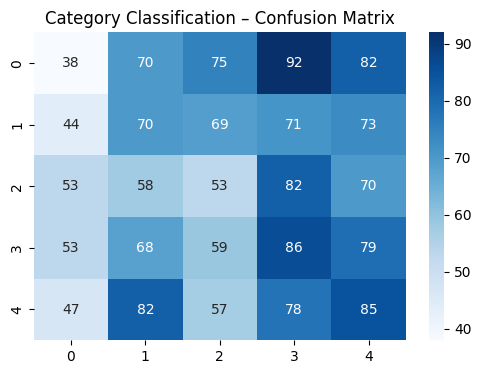

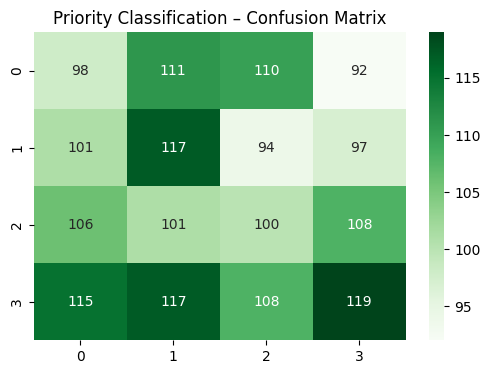

In [9]:
#STEP 9 — Confusion Matrix
#Category Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_cat_test, cat_predictions), annot=True, fmt='d', cmap='Blues')
plt.title("Category Classification – Confusion Matrix")
plt.show()
#Priority Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_pri_test, pri_predictions), annot=True, fmt='d', cmap='Greens')
plt.title("Priority Classification – Confusion Matrix")
plt.show()

In [10]:
#STEP 10 — Predict for New Ticket
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

# New ticket to test
new_ticket = "My laptop keeps crashing after the latest update."

# Preprocess
clean_text = preprocess(new_ticket)

# Convert to TF-IDF features
X_new = tfidf.transform([clean_text])

# Predict
category_pred = model_category.predict(X_new).item()
priority_pred = model_priority.predict(X_new).item()

print("Predicted Category:", category_pred)
print("Predicted Priority:", priority_pred)

Predicted Category: Product inquiry
Predicted Priority: Medium
